# Analzye collected data

Here, we gather the data collected from the different models and compare them to human data.

### Import

In [1]:
import pandas as pd
import plotly.express as px
from pathlib import Path
import  matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix,ConfusionMatrixDisplay
import numpy as np
import seaborn as sns
import pingouin as pg

## Parameters

In [2]:
MODELS = [
    "gpt-5.4-nano-2026-03-17",
    "gpt-5.4-mini-2026-03-17",
    "gpt-5.4",
]

### Functions

In [ ]:
def read_scores_from_model(model):

    model_name = model + "_"
    files = list(Path("results").glob(f"{model_name}*.csv"))

    df = pd.DataFrame([])

    print(f"Gathered data for model {model} from {len(files)} files.")
    for f in files:
        df_data = pd.read_csv(f'results/{f.name}')
        df_data["run"] = f.name[-5:-4]
        df = pd.concat([df, df_data], ignore_index=True)

    df["model"] = model
    df["id"] = df["id"].astype(int)

    return df


def summarize_scores_from_model(df, model):
    summary = df.groupby("id").agg({"score": ["mean", "std", "sem"]}).reset_index()
    summary.columns = summary.columns.get_level_values(1)
    #summary.columns = ['id', f'{model}_mean', f'{model}_std', f'{model}_sem']
    summary.columns = ['id', 'score_mean', 'score_std', 'score_sem']
    print(f"Summarized data for model {model}.")

    return summary


def collate_human_and_llm_data_wide(MODELS: list) -> pd.DataFrame:
    
    # fetch human data
    df = pd.read_csv("data/iCO-Eval2_summarizedRatings.csv", sep=";")

    # fetch, aggregate and merge LLm data
    for model in MODELS:
        df_model = read_scores_from_model(model)
        summary_model = summarize_scores_from_model(df_model, model)
        summary_model.columns = ['id', f'{model}_mean', f'{model}_std', f'{model}_sem']
        df = pd.merge(df, summary_model, left_on="CODE", right_on="id", how="left").drop(columns='id')
        
    return df


def collate_human_and_llm_data_long(MODELS: list) -> pd.DataFrame:
    
    # fetch human data
    df = pd.read_csv("data/iCO-Eval2_summarizedRatings.csv", sep=";")
    df.drop(columns=["CONTEXT QUESTION", "CRITICAL UTTERANCE", "CORRECT RESPONSE (0=no; 1=yes)", "FUN_std", "FUN_sem", "COH_std", "COH_sem", "DIR_std", "DIR_sem", "PRE_std", "PRE_sem", "SSI_std", "SSI_sem", "CER_std", "CER_sem"], inplace=True) #this is not really necessary

    # add information such as condition and set
    ref = df

    df["evaluator"] = "human"

    # fetch, aggregate and merge LLm data
    for model in MODELS:
        df_model = read_scores_from_model(model)
        summary_model = summarize_scores_from_model(df_model, model)
        
        # only take mean, leave sd and std out
        summary_model  = summary_model[["id", "score_mean"]] 
        summary_model.rename(columns={"score_mean": "FUN_mean", "id": "CODE"}, inplace=True)
        
        # generate certainty score
        summary_model["CER_mean"] = ((summary_model["FUN_mean"] - 4).abs())+1
        
        # add evaluator column to indicate which model the scores are from
        summary_model["evaluator"] = model

        # add SET and CONDITION infformation from the reference human data
        summary_model = summary_model.merge(ref[["CODE", "SET (1=SA-matched;2=non-SA-matched)", "CONDITION"]], on="CODE", how="left", validate="m:1")

        # concatenate with data so far
        df = pd.concat([df, summary_model], axis=0, join='outer').reset_index(drop=True)
        
    # rename SET column
    df = df.rename(columns={"SET (1=SA-matched;2=non-SA-matched)": "SET"})

    return df


def compare_to_human(df_long: pd.DataFrame) -> pd.DataFrame:
    '''Classify scores into 3 classes (score < 4: no, score == 4, unsure, score > 4: yes) for all evaluators and compare moel responses to human ones.'''

    # create a reference data frame containing categorized human scores
    ref = df_long.loc[df_long["evaluator"] == "human", ["CODE", "FUN_mean"]]
    ref.loc[ref["FUN_mean"] <= 4, 'reference'] = "no"
    ref.loc[ref["FUN_mean"] > 4, 'reference'] = "yes"
    ref

    # merge it to main df_long
    df_long = df_long.merge(ref[["CODE", "reference"]], on="CODE", how="left", validate="m:1")

    # categorize human and model scores
    df_long.loc[df_long["FUN_mean"] <= 4, 'response'] = "no"
    df_long.loc[df_long["FUN_mean"] > 4, 'response'] = "yes"

    # compare model nad human to generate accuracy
    df_long['accuracy'] = df_long['response'] == df_long['reference']

    return df_long


def rescale(series: pd.Series, min: int, max: int) -> pd.Series:
    return (series - min) / (max - min)


def conf_matrix(df_long: pd.DataFrame, MODELS: list):
    '''For each model, creates 3 confusion matrices (direct, indirect, all) and plots it.'''

    for model in MODELS:

        for c in ['direct', 'indirect', 'all']:

            # extract data
            if c == 'all':
                y_true = df_long.loc[df_long['evaluator'] == model, 'reference']
                y_pred_cat = df_long.loc[df_long['evaluator'] == model, 'response']
            else:
                y_true = df_long.loc[(df_long['evaluator'] == model) & (df_long['CONDITION'] == c), 'reference']
                y_pred_cat = df_long.loc[(df_long['evaluator'] == model) & (df_long['CONDITION'] == c), 'response']


            # confusion matrix
            cm = confusion_matrix(
                y_true,
                y_pred_cat,
                normalize='all',
                labels=['no', 'yes']
                )
            print(type(cm))
            np.savetxt(f"analysis/confusion_matrix_{model}_{c}.txt", cm, fmt="%.2f")

            ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred_cat,
            display_labels=["no", "yes"],
            cmap='Blues',
            normalize='all',
            )
            plt.title(f"{model}\n{c}")
            plt.savefig(f"analysis/confusion_matrix_figure_{model}_{c}.png")

def roc(df_long: pd.DataFrame, MODELS: list):
    '''Generates and saves ROC curve and AUC values for the models.'''

    for model in MODELS:

        # extract data
        y_true = df_long.loc[df_long['evaluator'] == model, 'reference']
        y_pred_cont = (df_long.loc[df_long['evaluator'] == model, 'FUN_mean'] -1 ) / 7

        # roc curve
        fpr, tpr, _ = roc_curve(y_true, y_pred_cont, pos_label = 'yes')
        roc_auc = auc(fpr, tpr)
        print(type(roc_auc))
        with open(f"analysis/roc_auc_{model}.txt", "w") as f:
            f.write(f"{roc_auc:.2f}")
        
        # plot
        plt.plot(fpr, tpr, label=f"{model} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlim([0,1])
    plt.ylim([0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC curve")
    plt.legend()
    plt.savefig(f"analysis/roc_curve.png")

    return


def descriptive_values(df_long: pd.DataFrame, dv: str, ivs: list):
    '''
    Generates descriptive statistics (mean, sd, sem) for a dv after grouping by the indicated ivs.
    '''

    # aggregate
    aggregated = df_long.groupby(ivs).agg(
        mean=(dv, "mean"),
        sd=(dv, "std"),
        sem=(dv, "sem"),
    ).reset_index()

    # save
    suffix = "_X_".join(x for x in ivs)
    filename = f"analysis/{dv}_summarized_{suffix}.csv"
    aggregated.to_csv(filename, index=False)

    return aggregated


def descriptive_plots(df_long: pd.DataFrame, dv: str, ivs: list, dv_min: float, dv_max: float):
    '''
    Create and save a seaborn point plot for a dependent variable grouped by up to
    four independent variables.

    `ivs` must be of length 4. The elements of `ivs` are interpreted in the following order:
    `ivs[0]` as x-axis, `ivs[1]` as hue, `ivs[2]` as column facet, and `ivs[3]`
    as row facet. Use `None` for unused positions.
    '''

    # plot
    f = sns.catplot(
        data=df_long,
        x=ivs[0],
        y=dv,
        hue=ivs[1],
        col=ivs[2], 
        row=ivs[3],
        kind="point",
        markersize=3,
        dodge=0.2,
        errorbar="se",
        linestyle="none",
        capsize=0.1,
        err_kws={"linewidth": 1.5},
    )
    plt.ylim([dv_min, dv_max])
    plt.xticks(rotation=90)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    # save
    suffix = "_X_".join(x for x in ivs if x is not None)
    filename = f"analysis/{dv}_summarized_{suffix}.png"
    f.savefig(filename)
    plt.close(f.fig)





### Aggregation

In [44]:
df_wide =  collate_human_and_llm_data_wide(MODELS)
df_long = collate_human_and_llm_data_long(MODELS)
df_long = compare_to_human(df_long)


Gathered data for model gpt-5.4-nano-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-nano-2026-03-17.
Gathered data for model gpt-5.4-mini-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-mini-2026-03-17.
Gathered data for model gpt-5.4 from 28 files.
Summarized data for model gpt-5.4.
Gathered data for model gpt-5.4-nano-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-nano-2026-03-17.
Gathered data for model gpt-5.4-mini-2026-03-17 from 28 files.
Summarized data for model gpt-5.4-mini-2026-03-17.
Gathered data for model gpt-5.4 from 28 files.
Summarized data for model gpt-5.4.


### Certainty

In [69]:
descriptive_values(df_long, "CER_mean", ["evaluator", "CONDITION"])
descriptive_values(df_long, "CER_mean", ["evaluator", "CONDITION", "reference"])
descriptive_values(df_long, "CER_mean", ["evaluator", "CONDITION", "reference", "SET"])

descriptive_plots(df_long, "CER_mean", ["evaluator", "CONDITION", None, None], dv_min=1, dv_max=4)
descriptive_plots(df_long, "CER_mean", ["evaluator", "CONDITION", "reference", None], dv_min=1, dv_max=4)
descriptive_plots(df_long, "CER_mean", ["evaluator", "CONDITION", "reference", "SET"], dv_min=1, dv_max=4)


In [70]:
temp_var = df_long[
    (df_long["evaluator"] == "human") | (df_long["evaluator"] == MODELS[2])
]

aov = pg.mixed_anova(dv='CER_mean',
                        between='CONDITION',
                        within='evaluator',
                        subject='CODE',
                        effsize="ng2",
                        correction=True,
                        data=temp_var)
aov

,Source,SS,DF1,DF2,MS,F,p_unc,ng2,eps
0,CONDITION,59.121266,1,274,59.121266,119.725016,2.333605e-23,0.233221,NaN
1,evaluator,1.263702,1,274,1.263702,5.861414,1.612635e-02,0.006459,1.0
2,Interaction,0.760686,1,274,0.760686,3.528280,6.139211e-02,0.003898,NaN


### Categorized responses

In [71]:
descriptive_values(df_long, dv='accuracy', ivs=["evaluator", "CONDITION"])
descriptive_values(df_long, dv='accuracy', ivs=["evaluator", "CONDITION", "response"])
descriptive_values(df_long, dv='accuracy', ivs=["evaluator", "CONDITION", "response", "SET"])

descriptive_plots(df_long, "accuracy", ["evaluator", "CONDITION", None, None], dv_min=0, dv_max=1)
descriptive_plots(df_long, "accuracy", ["evaluator", "CONDITION", "reference", None], dv_min=0, dv_max=1)
descriptive_plots(df_long, "accuracy", ["evaluator", "CONDITION", "reference", "SET"], dv_min=0, dv_max=1)

#### Confusion Matrix

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


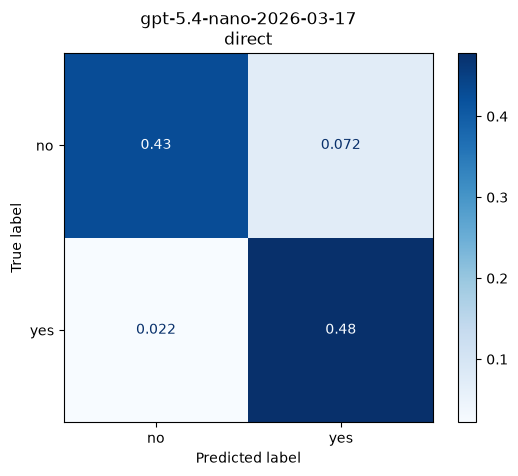

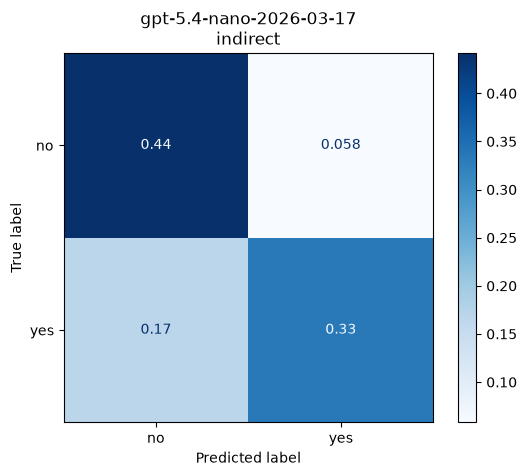

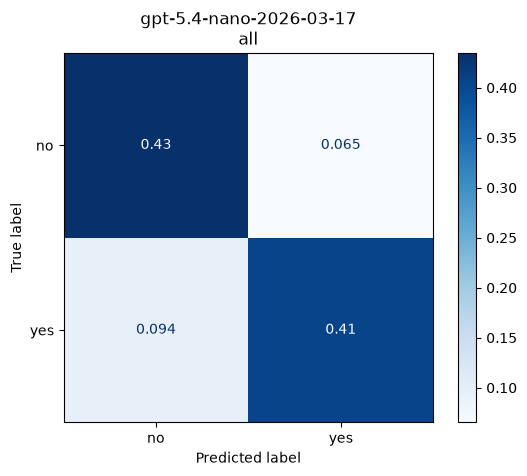

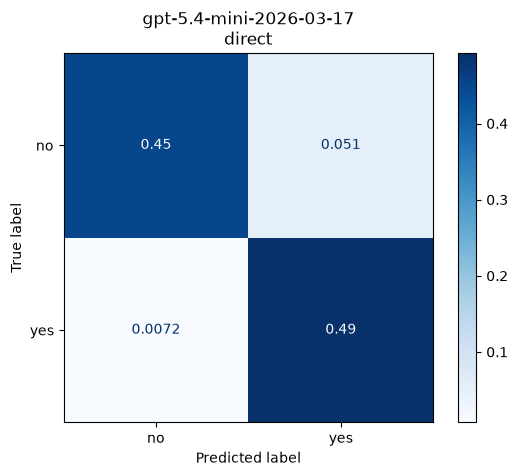

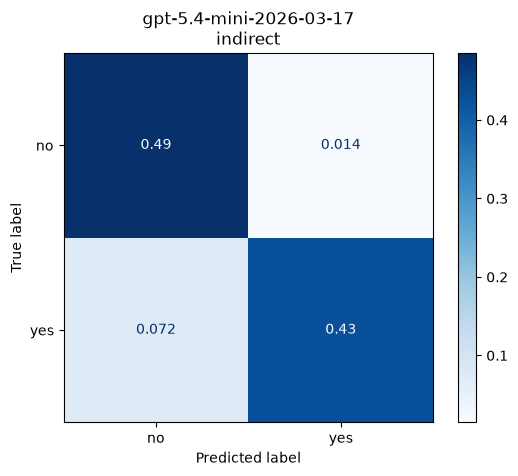

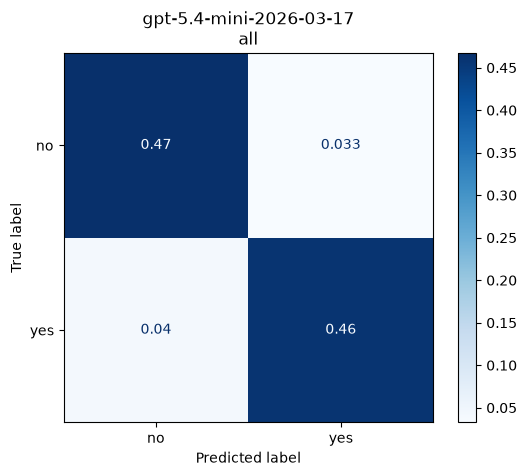

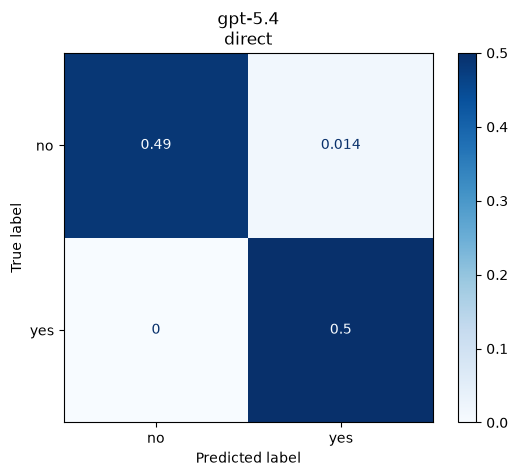

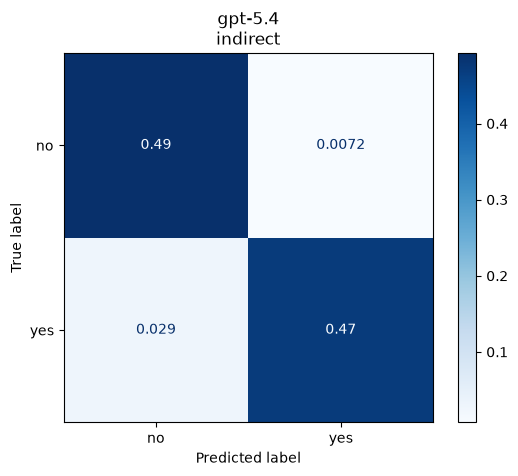

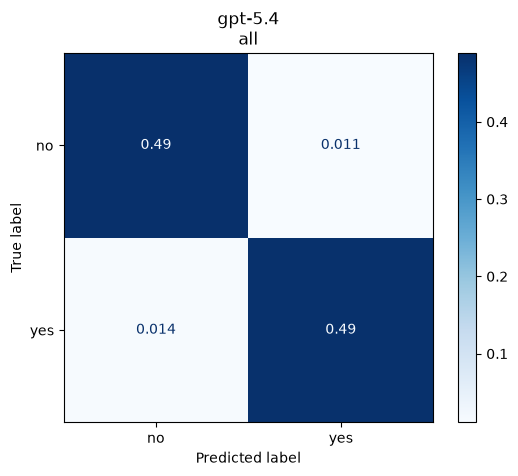

In [72]:
conf_matrix(df_long, MODELS)

#### ROC curve

<class 'float'>
<class 'float'>
<class 'float'>


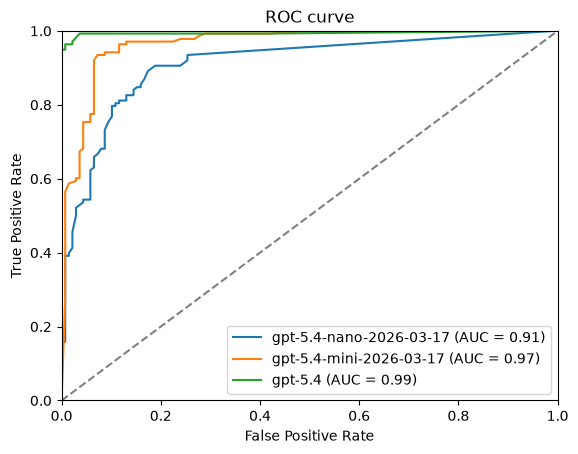

In [73]:
roc(df_long, MODELS)